# Heart Disease Prediction using Machine Learning

This project predicts heart disease using Machine Learning algorithms.

In [1]:

# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn


In [2]:

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## Upload Dataset

In [3]:

from google.colab import files
uploaded = files.upload()


Saving Heart_Disease_Prediction_Colab.ipynb to Heart_Disease_Prediction_Colab.ipynb


In [5]:

# Load Dataset
heart_data = pd.read_csv('dataset.csv')

# Display first 5 rows
heart_data.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67,1,2,126,458,1,0,144,0,2.3,2,2,2,0
1,57,0,0,158,384,0,1,133,0,6.2,0,4,0,0
2,43,0,3,111,286,0,0,130,0,2.8,1,0,2,1
3,71,1,2,189,515,1,1,149,0,2.1,1,2,1,1
4,36,0,0,142,303,0,0,107,1,3.6,1,0,0,1


In [6]:

# Dataset Information
print(heart_data.shape)
print(heart_data.info())
print(heart_data.isnull().sum())


(303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: i

In [7]:

# Statistical Summary
heart_data.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.00000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.00000,303.000000
mean,52.267327,0.544554,1.40264,146.511551,352.894389,0.471947,0.465347,134.610561,0.488449,3.030693,1.000000,1.980198,1.50165,0.491749
std,13.896179,0.498835,1.16925,31.336124,127.705381,0.500038,0.499623,39.731468,0.500693,1.786747,0.805609,1.437300,1.12725,0.500759
min,29.000000,0.000000,0.00000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,40.000000,0.000000,0.00000,119.000000,245.500000,0.000000,0.000000,99.000000,0.000000,1.400000,0.000000,1.000000,0.00000,0.000000
50%,53.000000,1.000000,1.00000,148.000000,354.000000,0.000000,0.000000,132.000000,0.000000,3.000000,1.000000,2.000000,2.00000,0.000000
75%,64.000000,1.000000,2.00000,174.000000,456.000000,1.000000,1.000000,169.000000,1.000000,4.600000,2.000000,3.000000,2.00000,1.000000
max,76.000000,1.000000,3.00000,199.000000,563.000000,1.000000,1.000000,201.000000,1.000000,6.200000,2.000000,4.000000,3.00000,1.000000


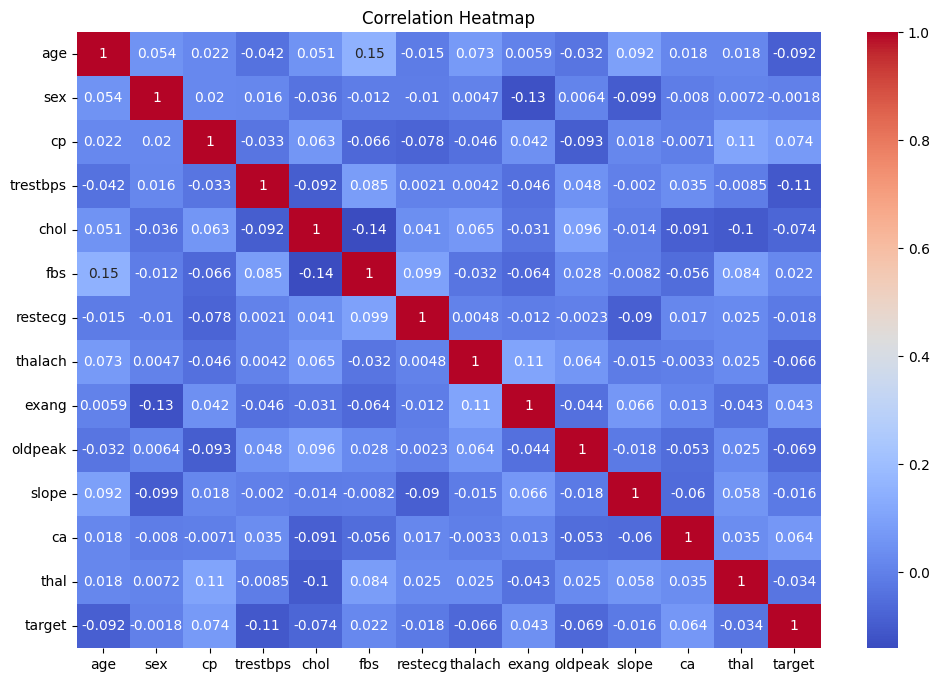

In [8]:

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(heart_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


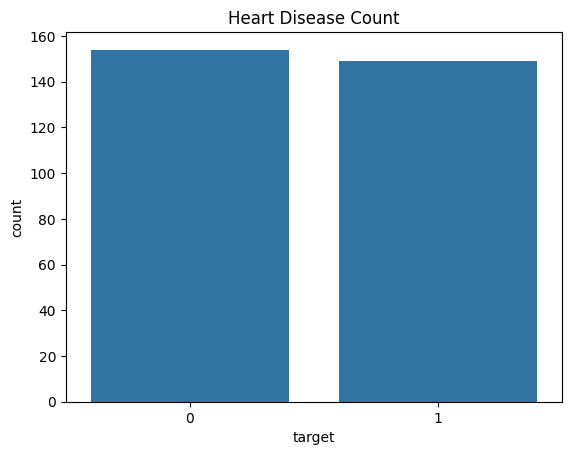

In [9]:

# Target Count Plot
sns.countplot(x='target', data=heart_data)
plt.title('Heart Disease Count')
plt.show()


In [10]:

# Split Features and Target
X = heart_data.drop(columns='target', axis=1)
Y = heart_data['target']


In [11]:

# Train Test Split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2
)


In [12]:

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [13]:

# Logistic Regression Model
model = LogisticRegression()

# Train model
model.fit(X_train, Y_train)


LogisticRegression()

In [14]:

# Training Accuracy
X_train_prediction = model.predict(X_train)
training_accuracy = accuracy_score(X_train_prediction, Y_train)

print('Training Accuracy : ', training_accuracy)


Training Accuracy :  0.6528925619834711


In [15]:

# Testing Accuracy
X_test_prediction = model.predict(X_test)
testing_accuracy = accuracy_score(X_test_prediction, Y_test)

print('Testing Accuracy : ', testing_accuracy)


Testing Accuracy :  0.47540983606557374


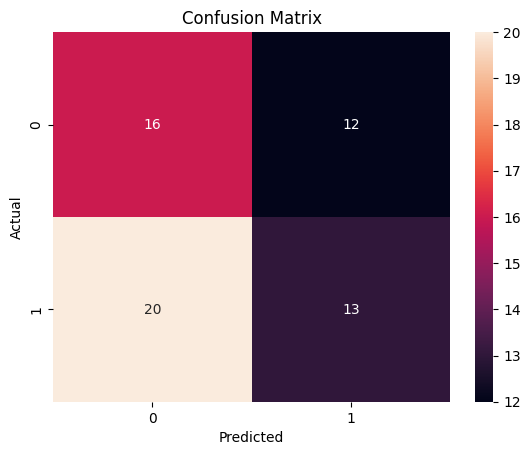

In [16]:

# Confusion Matrix
cm = confusion_matrix(Y_test, X_test_prediction)

sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [17]:

# Classification Report
print(classification_report(Y_test, X_test_prediction))


              precision    recall  f1-score   support

           0       0.44      0.57      0.50        28
           1       0.52      0.39      0.45        33

    accuracy                           0.48        61
   macro avg       0.48      0.48      0.47        61
weighted avg       0.49      0.48      0.47        61



In [18]:

# Heart Disease Prediction System
input_data = (52,1,0,125,212,0,1,168,0,1.0,2,2,3)

input_data_as_numpy_array = np.asarray(input_data)

input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

std_data = scaler.transform(input_data_reshaped)

prediction = model.predict(std_data)

print(prediction)

if prediction[0] == 0:
    print('The Person does not have Heart Disease')
else:
    print('The Person has Heart Disease')


[0]
The Person does not have Heart Disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [19]:

# Random Forest Model
rf_model = RandomForestClassifier()

rf_model.fit(X_train, Y_train)

rf_prediction = rf_model.predict(X_test)

rf_accuracy = accuracy_score(Y_test, rf_prediction)

print('Random Forest Accuracy : ', rf_accuracy)


Random Forest Accuracy :  0.47540983606557374
